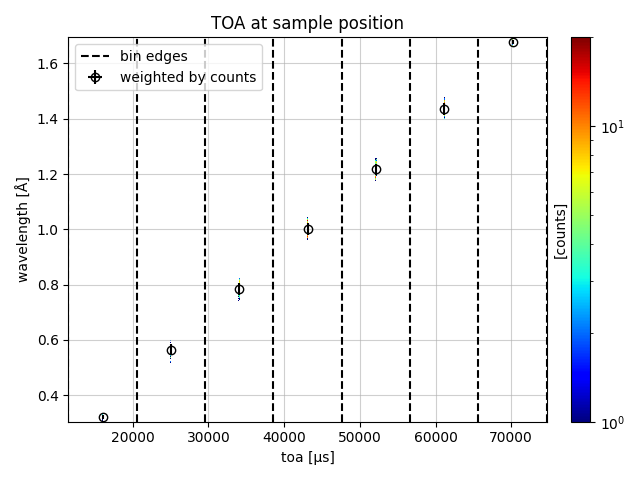

In [13]:
%matplotlib widget
import matplotlib.pyplot as plt
import scipp as sc
from trex.source import Source
from trex.instrument import Instrument
from trex.utils import centers_to_edges
import tof

central_wavelength = 1 * sc.Unit("Å")
mode = "High Flux"  # Chopper mode
rrm = 8
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
res = trex.model.run()


fig, ax = plt.subplots()
# Squeeze the pulse dimension since we only have one pulse
events_at_sample = res["Sample"].data.squeeze()
# Remove the events that don't make it to the detector
events_at_sample = events_at_sample[~events_at_sample.masks["blocked_by_others"]]
# Histogram and plot
toa_sample = events_at_sample.hist(wavelength=800, toa=1000).plot(
    norm="log", cbar=True, ax=ax, cmap="jet", title="TOA at sample position"
)

toa_min, toa_max = trex.calculate_toa_range_at("Sample")
toa_centers = trex.calculate_toa_at("Sample")
toa_bin_edges = centers_to_edges(toa_centers)

for edge in toa_bin_edges:
    vline = ax.axvline(x=edge.values, c="k", linestyle="--", label="bin edges")


toa_binned = events_at_sample.bin(toa=toa_bin_edges)
# Weighted mean of wavelength inside each bin
wavelength_mu = (
    toa_binned.bins.data * toa_binned.bins.coords["wavelength"]
).bins.sum() / toa_binned.bins.sum()

# Variance of wavelengths inside each bin
wavelength_var = (
    toa_binned.bins.data * (toa_binned.bins.coords["wavelength"] - wavelength_mu) ** 2
) / toa_binned.bins.sum()

# Weighted mean of TOA inside each bin
toa_mu = (
    toa_binned.bins.data * toa_binned.bins.coords["toa"]
).bins.sum() / toa_binned.bins.sum()

# Variance of TOA inside each bin
toa_var = (
    toa_binned.bins.data * (toa_binned.bins.coords["toa"] - toa_mu) ** 2
) / toa_binned.bins.sum()

ebplot = ax.errorbar(
    x=toa_mu.values,
    xerr=sc.sqrt(toa_var.hist()).values,
    y=wavelength_mu.values,
    yerr=sc.sqrt(wavelength_var.hist()).values,
    fmt="ok",
    linestyle="",
    mfc="none",
    label="weighted by counts",
)
ax.grid(alpha=0.6)
ax.set_xlim((toa_bin_edges.min().values, toa_bin_edges.max().values))
ax.legend(handles=[vline, ebplot])
fig.tight_layout()
plt.show()

In [14]:
import plopp as pp

toa_m3_edges = trex.calculate_toa_bin_edges_at("Monitor 3")
toa_det_edges = trex.calculate_toa_bin_edges_at("Detector")


toa_bin_to_plot = sc.linspace(
    "toa", toa_m3_edges.min(), toa_det_edges.max(), num=500 * (len(toa_m3_edges) - 1)
)
hist_m3 = res.detectors["Monitor 3"].data.hist(toa=toa_bin_to_plot)
hist_det = res.detectors["Detector"].data.hist(toa=toa_bin_to_plot)

pp.plot({"Monitor 3": hist_m3, "Detector": hist_det}, grid=True)  # type: ignore

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [15]:
res = trex.model.run()
toa_centers_m3 = trex.estimate_toa_centroid_at("Monitor 3", model_result=res)
toa_centers_det = trex.estimate_toa_centroid_at("Detector", model_result=res)

print(toa_centers_m3.data)
print(toa_centers_det.data)

<scipp.Variable> (toa: 7)    float64            [µs]  [15960.1, 24963.4, ..., 60942.7, 69945.9]
<scipp.Variable> (toa: 7)    float64            [µs]  [16253.3, 25478.1, ..., 62248.2, 71472]


In [16]:
wavelength = trex.estimate_incoming_wavelength(res)
wavelength_requested = trex.calculate_incoming_wavelength()

print(wavelength)
print(wavelength_requested)

<scipp.Variable> (wavelength: 7)    float64             [Å]  [0.322241, 0.565538, ..., 1.43461, 1.67699]
<scipp.Variable> (wavelength: 7)    float64             [Å]  [0.31857, 0.562273, ..., 1.43437, 1.67988]


In [17]:
ei = trex.estimate_incoming_energy(res)
ei_requested = trex.calculate_incoming_energy()

print(ei)
print(ei_requested)
print(ei.values)

<scipp.Variable> (energy: 7)    float64            [meV]  [787.797, 255.771, ..., 39.7473, 29.0882]
<scipp.Variable> (energy: 7)    float64            [meV]  [806.056, 258.75, ..., 39.7608, 28.9881]
[787.79726743 255.77113586 132.87968349  81.71774676  55.25750501
  39.74732747  29.08817141]
